# Ensemble Model

This notebook represents the entirety of the model and its evaluation code.

To run the entire notebook at once, choose "Runtime" from the menu and then "Run all" or press Ctrl + F9.

To run cells individually, press the play button in the top left corner of the cell or press Ctrl + Enter.

To input your own date range for testing the model, change the values of the `start_date` and `end_date` variables in the **Test the Model** section, matching the "YYYY-MM-DD" date format. After inputting the dates, run the cell and all subsequent cells.

## Data Collection
This code block is responsible for collecting stock data from Yahoo Finance using the `yfinance` library. The function `download_stock_data` takes a stock ticker symbol, a start date, and an end date as input parameters, and returns the stock data for that period. The data is then saved to a CSV file.

- `import yfinance as yf`: Imports the `yfinance` library and aliases it as `yf`.
- `download_stock_data`: Defines a function to download stock data.
- `ticker`, `start_date`, `end_date`: Specifies the stock ticker symbol and the date range for the data.
- `data = download_stock_data(ticker, start_date, end_date)`: Calls the function to download the data.
- `data.to_csv(f"{ticker}_data.csv")`: Saves the downloaded data to a CSV file named "AAPL_data.csv".

In [14]:
import yfinance as yf

def download_stock_data(ticker, start_date, end_date):
    stock_data = yf.download(ticker, start=start_date, end=end_date)
    return stock_data

ticker = "AAPL"
start_date = "2010-01-01"
end_date = "2024-01-01"
data = download_stock_data(ticker, start_date, end_date)
data.to_csv(f"01_{ticker}_data.csv")

[*********************100%***********************]  1 of 1 completed


## Data Preprocessing
This code block is responsible for preprocessing the stock data. The function `preprocess_data` reads the stock data from a CSV file, drops any missing values, renames the 'Price' column to 'Date', deletes the first and second rows, converts the 'Date' column to datetime format, and sets it as the index of the DataFrame. The preprocessed data is then saved to a new CSV file.

- `import pandas as pd`: Imports the `pandas` library and aliases it as `pd`.
- `preprocess_data`: Defines a function to preprocess the stock data.
- `file_path`: Specifies the path to the CSV file containing the raw stock data.
- `data = pd.read_csv(file_path)`: Reads the CSV file into a DataFrame.
- `data = data.dropna()`: Drops any rows with missing values.
- `data = data.rename(columns={'Price': 'Date'})`: Renames the 'Price' column to 'Date'.
- `data = data.drop(data.index[[0, 1]])`: Deletes the first and second rows of the DataFrame.
- `data['Date'] = pd.to_datetime(data['Date'])`: Converts the 'Date' column to datetime format.
- `data.set_index('Date', inplace=True)`: Sets the 'Date' column as the index of the DataFrame.
- `for col in data.columns: data[col] = pd.to_numeric(data[col], errors='coerce')`: Converts all columns to numeric format, coercing any errors to NaN.
- `return data`: Returns the preprocessed DataFrame.
- `if __name__ == "__main__":`: Checks if the script is being run directly.
- `file_path = "AAPL_data.csv"`: Specifies the path to the input CSV file.
- `data = preprocess_data(file_path)`: Calls the function to preprocess the data.
- `data.to_csv("AAPL_data_preprocessed.csv")`: Saves the preprocessed data to a CSV file named "AAPL_data_preprocessed.csv".

In [15]:
import pandas as pd

def preprocess_data(file_path):
    data = pd.read_csv(file_path)
    data = data.dropna()
    data = data.rename(columns={'Price': 'Date'})
    # Delete rows 1 and 3
    data = data.drop(data.index[[0, 1]])
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)
    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')
    return data

file_path = f"01_{ticker}_data.csv"
data = preprocess_data(file_path)
data.to_csv(f"02_{ticker}_data_preprocessed.csv")

## Feature Engineering
This code block is responsible for preprocessing stock data from a CSV file. The function `preprocess_data` reads the data, handles missing values, renames columns, deletes specific rows, converts the 'Date' column to datetime, sets it as the index, and ensures all other columns are numeric. The preprocessed data is then saved to a new CSV file.

- `import pandas as pd`: Imports the pandas library for data manipulation.
- `preprocess_data(file_path)`: Defines a function to preprocess the stock data.
- `data = pd.read_csv(file_path)`: Reads the stock data from the specified CSV file.
- `data = data.dropna()`: Drops any rows with missing values.
- `data = data.rename(columns={'Price': 'Date'})`: Renames the 'Price' column to 'Date'.
- `data = data.drop(data.index[[0, 1]])`: Deletes the first and second rows of the data.
- `data['Date'] = pd.to_datetime(data['Date'])`: Converts the 'Date' column to datetime format.
- `data.set_index('Date', inplace=True)`: Sets the 'Date' column as the index of the dataframe.
- `for col in data.columns: data[col] = pd.to_numeric(data[col], errors='coerce')`: Converts all columns to numeric, coercing errors.
- `return data`: Returns the preprocessed data.
- `if __name__ == "__main__":`: Ensures the following code runs only if the script is executed directly.
- `file_path = "AAPL_data.csv"`: Specifies the path to the CSV file containing the raw stock data.
- `data = preprocess_data(file_path)`: Calls the function to preprocess the data.
- `data.to_csv("AAPL_data_preprocessed.csv")`: Saves the preprocessed data to a new CSV file named "AAPL_data_preprocessed.csv".

In [16]:
def create_features(data):
    data['Return'] = data['Close'].pct_change()
    data['Volatility'] = data['Return'].rolling(window=21).std()
    data['Momentum'] = data['Close'].rolling(window=21).mean()
    data = data.dropna()
    return data

file_path = f"02_{ticker}_data_preprocessed.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
data = create_features(data)
data.to_csv(f"03_{ticker}_data_features.csv")

## Model Training
This code block is responsible for training a machine learning model using the feature-engineered stock data. The function `train_model` shifts the target variable to predict the next day's return, splits the data into training and testing sets, trains an XGBoost regression model on the training data, and evaluates its performance on the testing data using Mean Squared Error (MSE). The trained model is then saved to a file.

- `import xgboost as xgb`: Imports the `xgboost` library and aliases it as `xgb`.
- `import sklearn`: Imports the `sklearn` library.
- `import sys`: Imports the `sys` library.
- `from sklearn.model_selection import train_test_split`: Imports the `train_test_split` function from `sklearn.model_selection`.
- `from sklearn.metrics import mean_squared_error`: Imports the `mean_squared_error` function from `sklearn.metrics`.
- `train_model`: Defines a function to train the model.
- `data['Target_Return'] = data['Return'].shift(-1)`: Shifts the target variable to have tomorrow's return as the label.
- `data = data.dropna()`: Drops any rows with missing values.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Target_Return']`: Selects the target variable for the model.
- `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)`: Splits the data into training and testing sets.
- `model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000)`: Initializes the XGBoost regressor model.
- `model.fit(X_train, y_train)`: Trains the model on the training data.
- `y_pred = model.predict(X_test)`: Makes predictions on the testing data.
- `mse = mean_squared_error(y_test, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error: {mse}")`: Prints the Mean Squared Error.
- `return model`: Returns the trained model.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = train_model(data)`: Calls the function to train the model.
- `model.save_model("1yo_xgboost_model.json")`: Saves the trained model to a file named "1yo_xgboost_model.json".

In [17]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

def train_model(data):
    data['Target_Return'] = data['Return'].shift(-1) # shift target to have tomorrow's return as the label
    data = data.dropna()  # drop the last row where Target_Return is NaN
    X = data[['Volatility', 'Momentum']]
    y = data['Target_Return']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")

    return model

file_path = f"03_{ticker}_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = train_model(data)
model.save_model("1yo_xgboost_model.json")

Mean Squared Error: 0.0003978074924251468


## Model Evaluation
This code block is responsible for evaluating the performance of the trained machine learning model on the feature-engineered stock data. The function `evaluate_model` takes the trained model and the data as input, makes predictions on the data, and calculates the Mean Squared Error (MSE) of the predictions. The MSE is then printed to the console.

- `evaluate_model`: Defines a function to evaluate the model.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Return']`: Selects the target variable for the model.
- `y_pred = model.predict(X)`: Makes predictions on the data.
- `mse = mean_squared_error(y, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error: {mse}")`: Prints the Mean Squared Error.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = xgb.XGBRegressor()`: Initializes the XGBoost regressor model.
- `model.load_model("1yo_xgboost_model.json")`: Loads the trained model from a file named "1yo_xgboost_model.json".
- `evaluate_model(model, data)`: Calls the function to evaluate the model.

In [18]:
def evaluate_model(model, data):
    X = data[['Volatility', 'Momentum']]
    y = data['Return']
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    print(f"Mean Squared Error: {mse}")

file_path = f"03_{ticker}_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = xgb.XGBRegressor()
model.load_model("1yo_xgboost_model.json")
evaluate_model(model, data)

Mean Squared Error: 0.0004625809514488238


## Trading Strategy
This code block is responsible for implementing a trading strategy based on the predictions of the trained machine learning model. The function `implement_strategy` takes the trained model and the feature-engineered stock data as input, makes predictions on the data, and generates trading signals based on the predicted returns. The strategy's returns are then calculated and saved to a new CSV file.

- `implement_strategy`: Defines a function to implement the trading strategy.
- `data['Predicted_Return']`: Adds a new column to the dataframe with the predicted returns from the model.
- `data['Signal']`: Adds a new column to the dataframe with trading signals based on the predicted returns (1 for buy, -1 for sell).
- `data['Strategy_Return']`: Adds a new column to the dataframe with the returns of the trading strategy, aligning the signal with tomorrow's actual return.
- `file_path = "AAPL_data_features.csv"`: Specifies the path to the CSV file containing the feature-engineered stock data.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the feature-engineered stock data from the CSV file.
- `model = xgb.XGBRegressor()`: Initializes the XGBoost regressor model.
- `model.load_model("1yo_xgboost_model.json")`: Loads the trained model from a file named "1yo_xgboost_model.json".
- `data = implement_strategy(model, data)`: Calls the function to implement the trading strategy.
- `data.to_csv("AAPL_strategy.csv")`: Saves the data with the trading strategy to a CSV file named after the ticker with "_strategy.csv" appended.

In [19]:
def implement_strategy(model, data):
    # Get prediction for tomorrow's return using today's data
    data.loc[:, 'Predicted_Return'] = model.predict(data[['Volatility', 'Momentum']])
    data.loc[:, 'Signal'] = data['Predicted_Return'].apply(lambda x: 1 if x > 0 else -1)
    # Align the signal with tomorrow's actual return
    data.loc[:, 'Strategy_Return'] = data['Signal'].shift(1) * data['Return']
    data = data.dropna()
    return data

file_path = f"03_{ticker}_data_features.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
model = xgb.XGBRegressor()
model.load_model("1yo_xgboost_model.json")
data = implement_strategy(model, data)
data.to_csv(f"04_{ticker}_strategy.csv")

## Backtesting
This code block is responsible for backtesting the trading strategy by calculating the cumulative returns of both the strategy and the market. The function `backtest_strategy` takes the stock data with the implemented strategy as input, computes the cumulative returns, and saves the results to a new CSV file.

- `backtest_strategy`: Defines a function to backtest the trading strategy.
- `data['Cumulative_Strategy_Return']`: Adds a new column to the DataFrame with the cumulative returns of the trading strategy.
- `data['Cumulative_Market_Return']`: Adds a new column to the DataFrame with the cumulative returns of the market.
- `file_path = "AAPL_strategy.csv"`: Specifies the path to the CSV file containing the stock data with the implemented strategy.
- `data = pd.read_csv(file_path, index_col='Date', parse_dates=True)`: Reads the stock data with the implemented strategy from the CSV file.
- `data = backtest_strategy(data)`: Calls the function to backtest the trading strategy.
- `data.to_csv("AAPL_backtest.csv")`: Saves the data with the backtesting results to a CSV file named after the ticker with "_backtest.csv" appended.

In [20]:
def backtest_strategy(data):
    data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()
    data['Cumulative_Market_Return'] = (1 + data['Return']).cumprod()
    return data

file_path = f"04_{ticker}_strategy.csv"
data = pd.read_csv(file_path, index_col='Date', parse_dates=True)
data = backtest_strategy(data)
data.to_csv(f"05_{ticker}_backtest.csv")

## Test the Model
This code block is responsible for testing the trained machine learning model on new, unseen stock data. The function `test_model` takes the trained model and the new stock data as input, makes predictions on the new data, and calculates the Mean Squared Error (MSE) of the predictions. The MSE is then printed to the console. Additionally, the code downloads new stock data, preprocesses it, creates new features, tests the model, and implements the trading strategy on the new data.

- `test_model`: Defines a function to test the model.
- `X = data[['Volatility', 'Momentum']]`: Selects the features for the model.
- `y = data['Return']`: Selects the target variable for the model.
- `y_pred = model.predict(X)`: Makes predictions on the new data.
- `mse = mean_squared_error(y, y_pred)`: Calculates the Mean Squared Error of the predictions.
- `print(f"Mean Squared Error on unseen data: {mse}")`: Prints the Mean Squared Error.
- `start_date = "2020-01-01"`: Specifies the start date for downloading new stock data.
- `end_date = "2024-06-01"`: Specifies the end date for downloading new stock data.
- `new_data = download_stock_data(ticker, start_date, end_date)`: Downloads the new stock data.
- `new_data.to_csv(f"06_{ticker}_new_data.csv")`: Saves the new stock data to a CSV file.
- `prep_data = preprocess_data(f"06_{ticker}_new_data.csv")`: Preprocesses the new stock data.
- `new_features = create_features(prep_data)`: Creates new features for the new stock data.
- `new_features.to_csv(f"07_{ticker}_new_data_features.csv")`: Saves the new stock data with features to a CSV file.
- `test_model(model, new_features)`: Calls the function to test the model on the new data.
- `new_features.to_csv(f"08_{ticker}_new_data_with_predictions.csv")`: Saves the new stock data with predictions to a CSV file.
- `model_and_signals = implement_strategy(model, new_features)`: Implements the trading strategy on the new data.
- `model_and_signals.to_csv(f"09_{ticker}_new_data_with_signals.csv")`: Saves the new stock data with trading signals to a CSV file.

In [27]:
def test_model(model, data):
    X = data[['Volatility', 'Momentum']]
    y = data['Return']
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    print(f"Mean Squared Error on unseen data: {mse}")

# Download new stock data
start_date = "2024-01-01"
end_date = "2024-06-01"
new_data = download_stock_data(ticker, start_date, end_date)
new_data.to_csv(f"06_{ticker}_new_data.csv")

# Preprocess the new stock data
prep_data = preprocess_data(f"06_{ticker}_new_data.csv")

# Create new features for the new stock data and ensure it's an independent copy
new_features = create_features(prep_data.copy())
new_features.to_csv(f"07_{ticker}_new_data_features.csv")

# Test the model on the new data
test_model(model, new_features)

# Save the test results to CSV
new_features.to_csv(f"08_{ticker}_new_data_with_predictions.csv")

# Implement the strategy on the new data
model_and_signals = implement_strategy(model, new_features)
model_and_signals.to_csv(f"09_{ticker}_new_data_with_signals.csv")

[*********************100%***********************]  1 of 1 completed

Mean Squared Error on unseen data: 0.0005260988886166611


## S&P 500
This code block is responsible for comparing the gains of the model's trading strategy against the S&P 500 index. It downloads the S&P 500 data, preprocesses it, creates features, and then backtests both the trading strategy and the S&P 500 index. The results are saved to new CSV files.

- `sp500_data = yf.download("^GSPC", start="2020-01-01", end="2024-06-01")`: Downloads the S&P 500 data for the specified date range.
- `sp500_data.to_csv("SP500_data.csv")`: Saves the downloaded S&P 500 data to a CSV file.
- `sp500_data = preprocess_data("SP500_data.csv")`: Preprocesses the S&P 500 data.
- `sp500_data.to_csv("SP500_data_preprocessed.csv")`: Saves the preprocessed S&P 500 data to a CSV file.
- `sp500_features = create_features(sp500_data)`: Creates new features for the S&P 500 data.
- `sp500_features.to_csv("SP500_data_features.csv")`: Saves the S&P 500 data with features to a CSV file.
- `model_and_signals = pd.read_csv(f"9_{ticker}_new_data_with_signals.csv", index_col='Date', parse_dates=True)`: Reads the trading strategy data with signals from a CSV file.
- `sp500_features = pd.read_csv("SP500_data_features.csv", index_col='Date', parse_dates=True)`: Reads the S&P 500 data with features from a CSV file.
- `sp500_features['Strategy_Return'] = sp500_features['Return']`: Assigns the daily return directly for the buy-and-hold S&P 500 strategy.
- `model_and_signals = backtest_strategy(model_and_signals)`: Backtests the trading strategy.
- `sp500_features = backtest_strategy(sp500_features)`: Backtests the S&P 500 buy-and-hold strategy.
- `model_and_signals.to_csv(f"{ticker}_new_data_with_signals_backtest.csv")`: Saves the backtested trading strategy data to a CSV file.
- `sp500_features.to_csv("SP500_data_features_backtest.csv")`: Saves the backtested S&P 500 data to a CSV file.

In [28]:
# Get S&P 500 data for 2024
sp500_data = yf.download("^GSPC", start=f"{start_date}", end=f"{end_date}")
sp500_data.to_csv("SP500_data.csv")

# Preprocess the S&P 500 data
sp500_data = preprocess_data("SP500_data.csv")
sp500_data.to_csv("SP500_data_preprocessed.csv")

# Create features for the S&P 500 data
sp500_features = create_features(sp500_data)
sp500_features.to_csv("SP500_data_features.csv")

# Compare the gains of the trading strategy vs. the S&P 500
model_and_signals = pd.read_csv(f"09_{ticker}_new_data_with_signals.csv", index_col='Date', parse_dates=True)
sp500_features = pd.read_csv("SP500_data_features.csv", index_col='Date', parse_dates=True)

# Add missing columns to the S&P 500 data
# For the buy-and-hold S&P 500, assign the daily return directly rather than creating signals.
sp500_features['Strategy_Return'] = sp500_features['Return']

#Backtest the trading strategy and the S&P 500
model_and_signals = backtest_strategy(model_and_signals)
sp500_features = backtest_strategy(sp500_features)

model_and_signals.to_csv(f"10_{ticker}_new_data_with_signals_backtest.csv")
sp500_features.to_csv("SP500_data_features_backtest.csv")

[*********************100%***********************]  1 of 1 completed


## Candlestick Charts
This code block is responsible for creating candlestick charts for the new stock data and the S&P 500 index using the `plotly` library. These candlestick charts represent the price movements over the testing period.

- `import plotly.graph_objects as go`: Imports the `plotly.graph_objects` module and aliases it as `go` for creating plots.

- `fig = go.Figure(data=[go.Candlestick(x=new_features.index, open=new_features['Open'], high=new_features['High'], low=new_features['Low'], close=new_features['Close'])])`: Creates a candlestick chart for the new stock data.
  - `x=new_features.index`: Sets the x-axis to the dates from the new stock data.
  - `open=new_features['Open']`: Sets the opening prices for the candlestick chart.
  - `high=new_features['High']`: Sets the high prices for the candlestick chart.
  - `low=new_features['Low']`: Sets the low prices for the candlestick chart.
  - `close=new_features['Close']`: Sets the closing prices for the candlestick chart.

- `fig.update_layout(title=f'{ticker} Candlestick Chart', xaxis_title='Date', yaxis_title='Price')`: Updates the layout of the chart.
  - `title=f'{ticker} Candlestick Chart'`: Sets the title of the chart.
  - `xaxis_title='Date'`: Sets the label for the x-axis.
  - `yaxis_title='Price'`: Sets the label for the y-axis.

- `fig.show()`: Displays the candlestick chart for the new stock data.

The second part of the code creates a similar candlestick chart for the S&P 500 index.

- `fig = go.Figure(data=[go.Candlestick(x=sp500_features.index, open=sp500_features['Open'], high=sp500_features['High'], low=sp500_features['Low'], close=sp500_features['Close'])])`: Creates a candlestick chart for the S&P 500 data.
  - `x=sp500_features.index`: Sets the x-axis to the dates from the S&P 500 data.
  - `open=sp500_features['Open']`: Sets the opening prices for the candlestick chart.
  - `high=sp500_features['High']`: Sets the high prices for the candlestick chart.
  - `low=sp500_features['Low']`: Sets the low prices for the candlestick chart.
  - `close=sp500_features['Close']`: Sets the closing prices for the candlestick chart.

- `fig.update_layout(title='S&P 500 Candlestick Chart', xaxis_title='Date', yaxis_title='Price')`: Updates the layout of the chart.
  - `title='S&P 500 Candlestick Chart'`: Sets the title of the chart.
  - `xaxis_title='Date'`: Sets the label for the x-axis.
  - `yaxis_title='Price'`: Sets the label for the y-axis.

- `fig.show()`: Displays the candlestick chart for the S&P 500 data.

In [29]:
# Create candlestick chart for the new data
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Candlestick(x=new_features.index,
        open=new_features['Open'],
        high=new_features['High'],
        low=new_features['Low'],
        close=new_features['Close'])])
# label it
fig.update_layout(title=f'{ticker} Candlestick Chart',
                        xaxis_title='Date',
                        yaxis_title='Price')
fig.show()

# Create candlestick chart for the S&P 500 data
fig = go.Figure(
    data=[go.Candlestick(x=sp500_features.index,
        open=sp500_features['Open'],
        high=sp500_features['High'],
        low=sp500_features['Low'],
        close=sp500_features['Close'])])
# label it
fig.update_layout(title='S&P 500 Candlestick Chart',
                        xaxis_title='Date',
                        yaxis_title='Price')
fig.show()

## Performance Metrics
This code block is responsible for calculating various performance metrics for both the trading strategy and the S&P 500 index. The metrics include the Sharpe ratio, maximum drawdown, annualized return, Sortino ratio, and Calmar ratio. The results are then printed to the console and saved to a CSV file.

### `calculate_sharpe_ratio`
A function to calculate the Sharpe ratio for insight into how well the strategy performs relative to its risk.
  - `returns = data['Return']`: Selects the returns from the data.
  - `sharpe_ratio = returns.mean() / returns.std()`: Calculates the Sharpe ratio as the mean return divided by the standard deviation of returns.
  - `return sharpe_ratio`: Returns the Sharpe ratio.
- `sharpe_ratio_model = calculate_sharpe_ratio(model_and_signals)`: Calculates the Sharpe ratio for the trading strategy.
- `sharpe_ratio_sp500 = calculate_sharpe_ratio(sp500_features)`: Calculates the Sharpe ratio for the S&P 500.
- `print(f"Sharpe Ratio for Trading Strategy: {sharpe_ratio_model}")`: Prints the Sharpe ratio for the trading strategy.
- `print(f"Sharpe Ratio for S&P 500: {sharpe_ratio_sp500}")`: Prints the Sharpe ratio for the S&P 500.

### `calculate_max_drawdown`
A function to calculate the maximum drawdown (MDD), which is a key metric for assessing the risk of the strategy by measuring the largest decline in value from a peak to a trough before a new peak is achieved.
  - `cum_returns = data['Cumulative_Strategy_Return']`: Selects the cumulative returns from the data.
  - `max_return = cum_returns.cummax()`: Calculates the cumulative maximum returns.
  - `drawdown = (cum_returns - max_return) / max_return`: Calculates the drawdown as the difference between cumulative returns and cumulative maximum returns, divided by cumulative maximum returns.
  - `max_drawdown = drawdown.min()`: Finds the minimum drawdown.
  - `return max_drawdown`: Returns the maximum drawdown.
- `max_drawdown_model = calculate_max_drawdown(model_and_signals)`: Calculates the maximum drawdown for the trading strategy.
- `max_drawdown_sp500 = calculate_max_drawdown(sp500_features)`: Calculates the maximum drawdown for the S&P 500.
- `print(f"Maximum Drawdown for Trading Strategy: {max_drawdown_model}")`: Prints the maximum drawdown for the trading strategy.
- `print(f"Maximum Drawdown for S&P 500: {max_drawdown_sp500}")`: Prints the maximum drawdown for the S&P 500.

### `calculate_annualized_return`
A function to calculate the annualized return, for simple comparison across different time horizons.
  - `cum_return = data['Cumulative_Strategy_Return']`: Selects the cumulative returns from the data.
  - `start_date = cum_return.index[0]`: Gets the start date of the data.
  - `end_date = cum_return.index[-1]`: Gets the end date of the data.
  - `years = (end_date - start_date).days / 365`: Calculates the number of years between the start and end dates.
  - `annualized_return = (cum_return.iloc[-1] ** (1 / years)) - 1`: Calculates the annualized return.
  - `return annualized_return`: Returns the annualized return.
- `annualized_return_model = calculate_annualized_return(model_and_signals)`: Calculates the annualized return for the trading strategy.
- `annualized_return_sp500 = calculate_annualized_return(sp500_features)`: Calculates the annualized return for the S&P 500.
- `print(f"Annualized Return for Trading Strategy: {annualized_return_model}")`: Prints the annualized return for the trading strategy.
- `print(f"Annualized Return for S&P 500: {annualized_return_sp500}")`: Prints the annualized return for the S&P 500.

### `calculate_sortino_ratio`
A function to calculate the Sortino ratio, which evaluates the risk-adjusted return of an investment by focusing only on downside risk, rather than total volatility.
  - `returns = data['Return']`: Selects the returns from the data.
  - `downside_returns = returns[returns < 0]`: Selects the downside returns (negative returns).
  - `sortino_ratio = returns.mean() / downside_returns.std()`: Calculates the Sortino ratio as the mean return divided by the standard deviation of downside returns.
  - `return sortino_ratio`: Returns the Sortino ratio.
- `sortino_ratio_model = calculate_sortino_ratio(model_and_signals)`: Calculates the Sortino ratio for the trading strategy.
- `sortino_ratio_sp500 = calculate_sortino_ratio(sp500_features)`: Calculates the Sortino ratio for the S&P 500.
- `print(f"Sortino Ratio for Trading Strategy: {sortino_ratio_model}")`: Prints the Sortino ratio for the trading strategy.
- `print(f"Sortino Ratio for S&P 500: {sortino_ratio_sp500}")`: Prints the Sortino ratio for the S&P 500.

### `calculate_calmar_ratio`
A function to calculate the Calmar ratio for assessing the risk-adjusted performance of the strategy, especially when there is a significant downside risk.
  - `cum_return = data['Cumulative_Strategy_Return']`: Selects the cumulative returns from the data.
  - `max_drawdown = calculate_max_drawdown(data)`: Calculates the maximum drawdown.
  - `calmar_ratio = cum_return.iloc[-1] / abs(max_drawdown)`: Calculates the Calmar ratio as the cumulative return divided by the absolute value of the maximum drawdown.
  - `return calmar_ratio`: Returns the Calmar ratio.
- `calmar_ratio_model = calculate_calmar_ratio(model_and_signals)`: Calculates the Calmar ratio for the trading strategy.
- `calmar_ratio_sp500 = calculate_calmar_ratio(sp500_features)`: Calculates the Calmar ratio for the S&P 500.
- `print(f"Calmar Ratio for Trading Strategy: {calmar_ratio_model}")`: Prints the Calmar ratio for the trading strategy.
- `print(f"Calmar Ratio for S&P 500: {calmar_ratio_sp500}")`: Prints the Calmar ratio for the S&P 500.

### Store the Metrics
- `performance_metrics`: Creates a dictionary to store all the performance metrics.
- `performance_metrics_df = pd.DataFrame(performance_metrics, index=['Trading Strategy', 'S&P 500'])`: Converts the performance metrics dictionary to a DataFrame.
- `performance_metrics_df.to_csv("performance_metrics.csv")`: Saves the performance metrics DataFrame to a CSV file.
- `print(performance_metrics_df)`: Prints the performance metrics DataFrame.

In [30]:
# Calculate the Sharpe ratio for the trading strategy and the S&P 500
def calculate_sharpe_ratio(data):
    returns = data['Return']
    sharpe_ratio = returns.mean() / returns.std()
    return sharpe_ratio

sharpe_ratio_model = calculate_sharpe_ratio(model_and_signals)
sharpe_ratio_sp500 = calculate_sharpe_ratio(sp500_features)

print(f"Sharpe Ratio for Trading Strategy: {sharpe_ratio_model}")
print(f"Sharpe Ratio for S&P 500: {sharpe_ratio_sp500}")

# Calculate the maximum drawdown for the trading strategy and the S&P 500
def calculate_max_drawdown(data):
    cum_returns = data['Cumulative_Strategy_Return']
    max_return = cum_returns.cummax()
    drawdown = (cum_returns - max_return) / max_return
    max_drawdown = drawdown.min()
    return max_drawdown

max_drawdown_model = calculate_max_drawdown(model_and_signals)
max_drawdown_sp500 = calculate_max_drawdown(sp500_features)

print(f"Maximum Drawdown for Trading Strategy: {max_drawdown_model}")
print(f"Maximum Drawdown for S&P 500: {max_drawdown_sp500}")

# Calculate the annualized return for the trading strategy and the S&P 500
def calculate_annualized_return(data):
    cum_return = data['Cumulative_Strategy_Return']
    start_date = cum_return.index[0]
    end_date = cum_return.index[-1]
    years = (end_date - start_date).days / 365
    annualized_return = (cum_return.iloc[-1] ** (1 / years)) - 1
    return annualized_return

annualized_return_model = calculate_annualized_return(model_and_signals)
annualized_return_sp500 = calculate_annualized_return(sp500_features)

print(f"Annualized Return for Trading Strategy: {annualized_return_model}")
print(f"Annualized Return for S&P 500: {annualized_return_sp500}")

# Calculate the Sortino ratio for the trading strategy and the S&P 500
def calculate_sortino_ratio(data):
    returns = data['Return']
    downside_returns = returns[returns < 0]
    sortino_ratio = returns.mean() / downside_returns.std()
    return sortino_ratio

sortino_ratio_model = calculate_sortino_ratio(model_and_signals)
sortino_ratio_sp500 = calculate_sortino_ratio(sp500_features)

print(f"Sortino Ratio for Trading Strategy: {sortino_ratio_model}")
print(f"Sortino Ratio for S&P 500: {sortino_ratio_sp500}")

# Calculate the Calmar ratio for the trading strategy and the S&P 500
def calculate_calmar_ratio(data):
    cum_return = data['Cumulative_Strategy_Return']
    max_drawdown = calculate_max_drawdown(data)
    calmar_ratio = cum_return.iloc[-1] / abs(max_drawdown)
    return calmar_ratio

calmar_ratio_model = calculate_calmar_ratio(model_and_signals)
calmar_ratio_sp500 = calculate_calmar_ratio(sp500_features)

print(f"Calmar Ratio for Trading Strategy: {calmar_ratio_model}")
print(f"Calmar Ratio for S&P 500: {calmar_ratio_sp500}")

# Write all the performance metrics to a CSV file
performance_metrics = {
    'Sharpe Ratio': [sharpe_ratio_model, sharpe_ratio_sp500],
    'Max Drawdown': [max_drawdown_model, max_drawdown_sp500],
    'Annualized Return': [annualized_return_model, annualized_return_sp500],
    'Sortino Ratio': [sortino_ratio_model, sortino_ratio_sp500],
    'Calmar Ratio': [calmar_ratio_model, calmar_ratio_sp500]
}

performance_metrics_df = pd.DataFrame(performance_metrics, index=['Trading Strategy', 'S&P 500'])
performance_metrics_df.to_csv("performance_metrics.csv")
print(performance_metrics_df)

Sharpe Ratio for Trading Strategy: 0.02208027387875366
Sharpe Ratio for S&P 500: 0.19245728094874762
Maximum Drawdown for Trading Strategy: -0.10127461515459708
Maximum Drawdown for S&P 500: -0.02482517373944416
Annualized Return for Trading Strategy: -0.11571842909466756
Annualized Return for S&P 500: 0.4281813637387546
Sortino Ratio for Trading Strategy: 0.03003156728244523
Sortino Ratio for S&P 500: 0.2920000531825463
Calmar Ratio for Trading Strategy: 9.72883867501641
Calmar Ratio for S&P 500: 42.17340937819316
                  Sharpe Ratio  Max Drawdown  Annualized Return  \
Trading Strategy      0.022080     -0.101275          -0.115718   
S&P 500               0.192457     -0.024825           0.428181   

                  Sortino Ratio  Calmar Ratio  
Trading Strategy       0.030032      9.728839  
S&P 500                0.292000     42.173409  


## Returns
This code block is responsible for plotting the cumulative returns of the trading strategy and the S&P 500 index. It uses the `matplotlib` library to create visualizations that compare the performance of the trading strategy against the market.

- `import matplotlib.pyplot as plt`: Imports the `matplotlib.pyplot` library and aliases it as `plt`.
- `plt.figure(figsize=(12, 6))`: Creates a new figure with a specified size of 12x6 inches.
- `plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Trading Strategy')`: Plots the cumulative returns of the trading strategy with a label.
- `plt.plot(sp500_features['Cumulative_Market_Return'], label='S&P 500')`: Plots the cumulative returns of the S&P 500 with a label.
- `plt.legend()`: Adds a legend to the plot to differentiate between the trading strategy and the S&P 500.
- `plt.title(f'Cumulative Returns of {ticker} Trading Strategy vs. S&P 500')`: Sets the title of the plot.
- `plt.xlabel('Date')`: Sets the label for the x-axis.
- `plt.ylabel('Cumulative Return')`: Sets the label for the y-axis.
- `plt.grid()`: Adds a grid to the plot for better readability.
- `plt.show()`: Displays the plot.

The second plot is similar but compares the cumulative strategy return and the cumulative market return within the trading strategy data. Cumulative market return reflects a simple buy-and-hold strategy.

- `plt.figure(figsize=(12, 6))`: Creates a new figure with a specified size of 12x6 inches.
- `plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Cumulative Strategy Return')`: Plots the cumulative strategy return with a label.
- `plt.plot(model_and_signals['Cumulative_Market_Return'], label='Cumulative Market Return')`: Plots the cumulative market return with a label.
- `plt.legend()`: Adds a legend to the plot to differentiate between the cumulative strategy return and the cumulative market return.
- `plt.title('Cumulative Strategy Return vs. Cumulative Market Return')`: Sets the title of the plot.
- `plt.xlabel('Date')`: Sets the label for the x-axis.
- `plt.ylabel('Cumulative Return')`: Sets the label for the y-axis.
- `plt.grid()`: Adds a grid to the plot for better readability.
- `plt.show()`: Displays the plot.

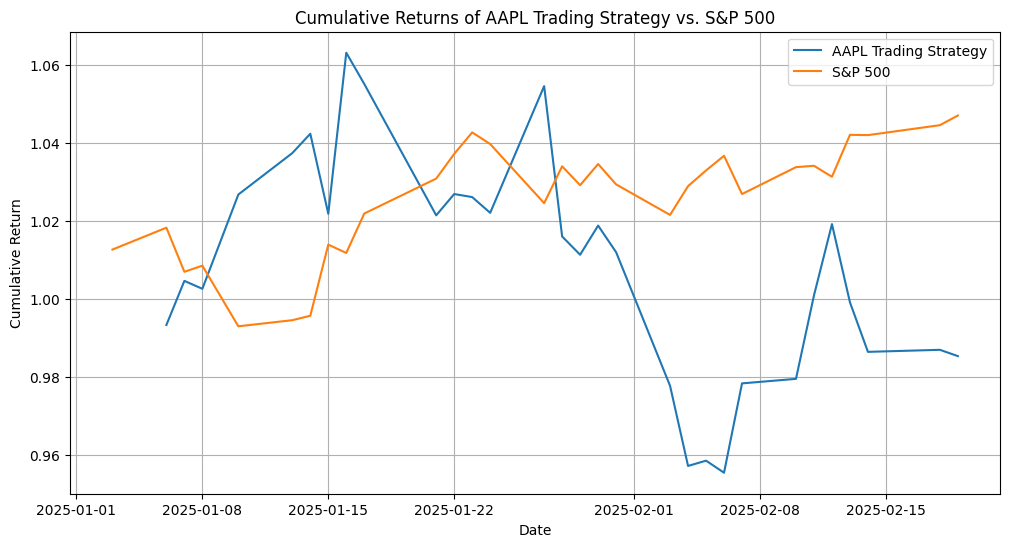

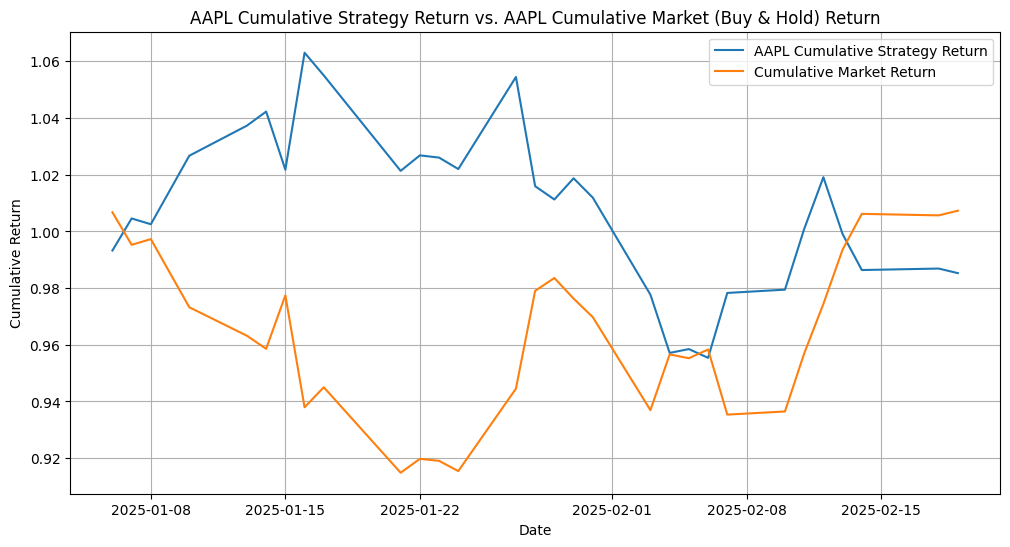

In [31]:
# Plot the cumulative returns of the trading strategy and the S&P 500
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Trading Strategy')
plt.plot(sp500_features['Cumulative_Market_Return'], label='S&P 500')
plt.legend()
plt.title(f'Cumulative Returns of {ticker} Trading Strategy vs. S&P 500')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

# Plot the cumulative strategy return and market return
plt.figure(figsize=(12, 6))
plt.plot(model_and_signals['Cumulative_Strategy_Return'], label=f'{ticker} Cumulative Strategy Return')
plt.plot(model_and_signals['Cumulative_Market_Return'], label='Cumulative Market Return')
plt.legend()
plt.title(f'{ticker} Cumulative Strategy Return vs. {ticker} Cumulative Market (Buy & Hold) Return')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid()
plt.show()

## Performance Metrics Visualization
This code block is responsible for visualizing the performance metrics of the trading strategy compared to the S&P 500. It creates bar charts to compare the Calmar ratio and other performance metrics between the trading strategy and the S&P 500.

- `performance_metrics_df['Calmar Ratio'].plot(kind='bar', figsize=(12, 6))`: Creates a bar chart to compare the Calmar ratio of the trading strategy and the S&P 500.
- `plt.title('Calmar Ratio of Trading Strategy vs. S&P 500')`: Sets the title of the bar chart.
- `plt.ylabel('Calmar Ratio')`: Sets the label for the y-axis.
- `plt.grid()`: Adds a grid to the bar chart for better readability.
- `plt.show()`: Displays the bar chart.

- `performance_metrics_df.drop('Calmar Ratio', axis=1).plot(kind='bar', figsize=(12, 6))`: Creates a bar chart to compare other performance metrics (excluding the Calmar ratio) of the trading strategy and the S&P 500.
- `plt.title('Performance Metrics of Trading Strategy vs. S&P 500')`: Sets the title of the bar chart.
- `plt.ylabel('Value')`: Sets the label for the y-axis.
- `plt.grid()`: Adds a grid to the bar chart for better readability.
- `plt.show()`: Displays the bar chart.

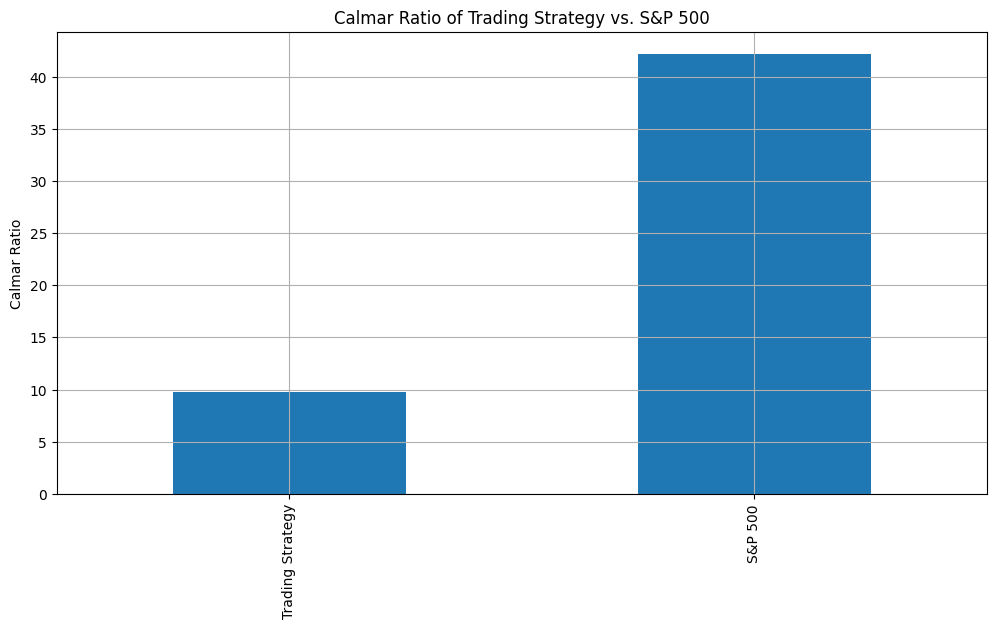

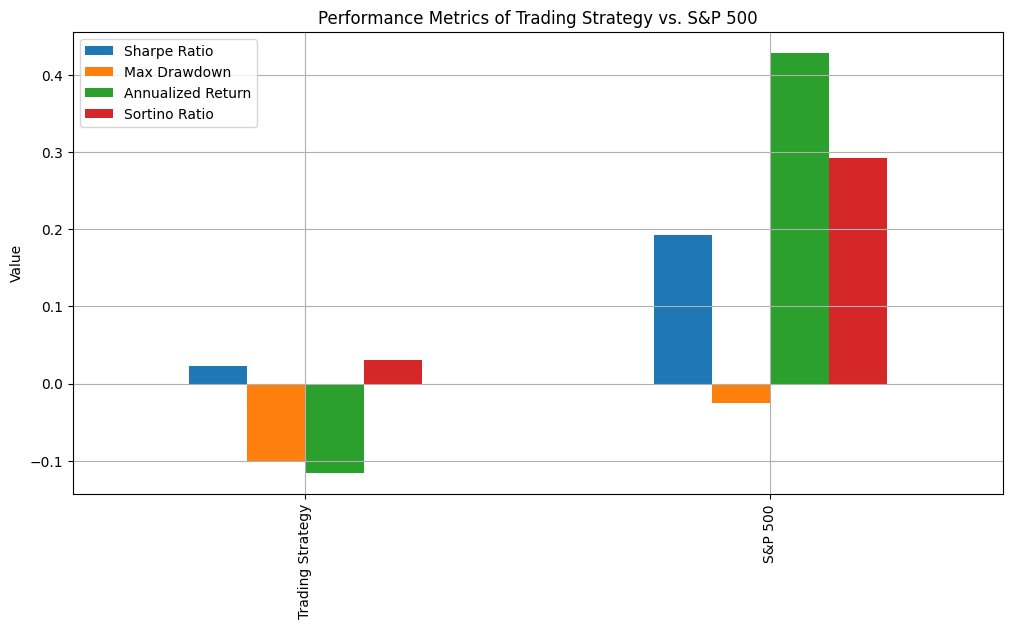

In [32]:
# Create a bar chart comparing the Calmar ratio of the trading strategy and the S&P 500
performance_metrics_df['Calmar Ratio'].plot(kind='bar', figsize=(12, 6))
plt.title('Calmar Ratio of Trading Strategy vs. S&P 500')
plt.ylabel('Calmar Ratio')
plt.grid()
plt.show()


# Create a bar chart of the performance metrics, excluding the Calmar ratio
performance_metrics_df.drop('Calmar Ratio', axis=1).plot(kind='bar', figsize=(12, 6))
plt.title('Performance Metrics of Trading Strategy vs. S&P 500')
plt.ylabel('Value')
plt.grid()
plt.show()